True
100 100
[0.00095229 0.00068158 0.00053803 0.00045094 0.00039404 0.0003554
 0.0003289  0.00031113 0.00030016 0.00029492 0.00029492 0.00030016
 0.00031113 0.0003289  0.0003554  0.00039404 0.00045094 0.00053803
 0.00068158 0.00095229]
True
100 100
[0.00285688 0.00204473 0.00161409 0.00135281 0.00118211 0.0010662
 0.00098669 0.0009334  0.00090049 0.00088476 0.00088476 0.00090049
 0.0009334  0.00098669 0.0010662  0.00118211 0.00135281 0.00161409
 0.00204473 0.00285688]
True
100 100
[0.00476146 0.00340789 0.00269015 0.00225468 0.00197018 0.001777
 0.00164449 0.00155566 0.00150082 0.0014746  0.0014746  0.00150082
 0.00155566 0.00164449 0.001777   0.00197018 0.00225468 0.00269015
 0.00340789 0.00476146]
True
100 100
[0.00666604 0.00477105 0.00376621 0.00315655 0.00275825 0.0024878
 0.00230228 0.00217793 0.00210114 0.00206443 0.00206443 0.00210114
 0.00217793 0.00230228 0.0024878  0.00275825 0.00315655 0.00376621
 0.00477105 0.00666604]
True
100 100
[0.00857063 0.0061342  0.00484227 0.0040

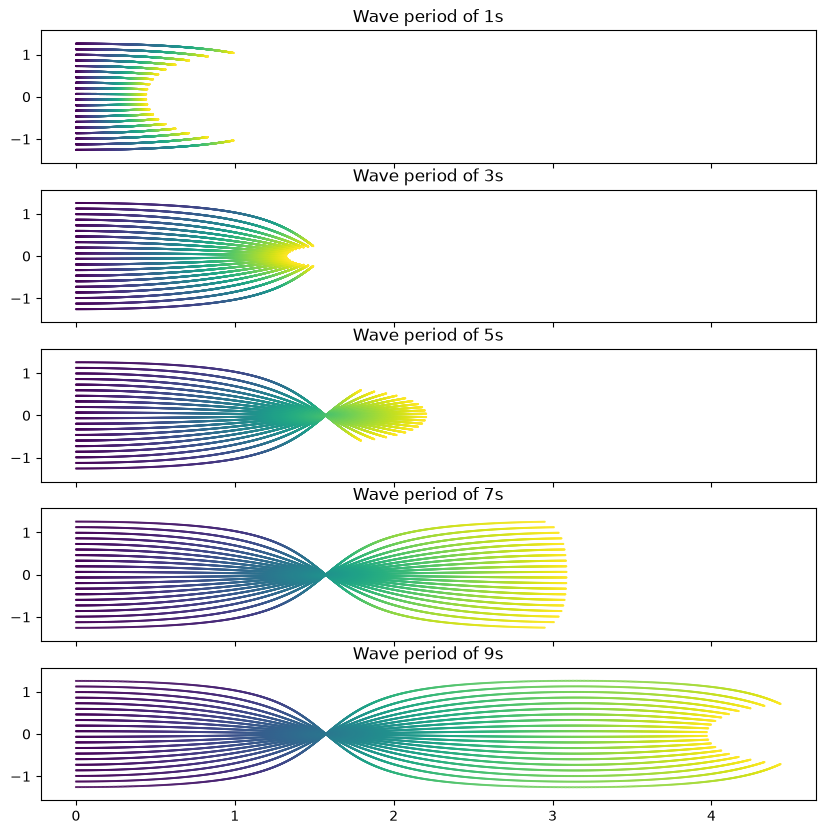

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from ocean_wave_tracing.ocean_wave_tracing import Wave_tracing

# Defining some properties of the medium
nx = 100; ny = 100 # number of grid points in x- and y-direction
x = np.linspace(0,np.pi/300,nx) # size x-domain [m] 
y = np.linspace(-np.pi*0.4,np.pi*0.4,ny) # size y-domain [m]
T = 3600000#0000 # simulation time [s]
#U=np.ones((nx,ny))*50
#U[nx//2:,:]=1

fig, ax = plt.subplots(5,1, figsize=(10,10), sharex=True)

for i in range(0,5):        
    # Define a wave tracing object
    wt = Wave_tracing(U=np.zeros((ny,nx)),V=np.zeros((ny,nx)), d=np.ones((ny,nx))*1000,
                        nx=nx, ny=ny, nt=1500,T=T,
                        dx=x[1]-x[0],dy=y[1]-y[0],
                        nb_wave_rays=20,
                        domain_X0=x[0], domain_XN=x[-1],
                        domain_Y0=y[0], domain_YN=y[-1], is_spherical=True
                        )

    # Set initial conditions
    wt.set_initial_condition(wave_period=2*i+1,
                                theta0=0)
    # Solve
    wt.solve()

    print(len(x), len(y))

    # Plot
    #pc=ax[i].pcolormesh(wt.x,wt.y,wt.U.isel(time=0),shading='auto');
    ax[i].set_title(f"Wave period of {2*i+1}s")
    #ax[i].set_xlim(x[0], 0.020)
    ax[i].set_ylim(-np.pi/2, np.pi/2)

    for ray_id in range(wt.nb_wave_rays):
        colors = np.arange(0, len(wt.ray_x[ray_id,:]), 1)
        ax[i].scatter(wt.ray_x[ray_id,:], wt.ray_y[ray_id,:], c=colors, cmap="viridis", s=0.2)

    print(wt.ray_x[:,1])



plt.show()

Text(0.5, 0.98, 'Evolution of ray parameters over a period of 10 hours, eastern propagation')

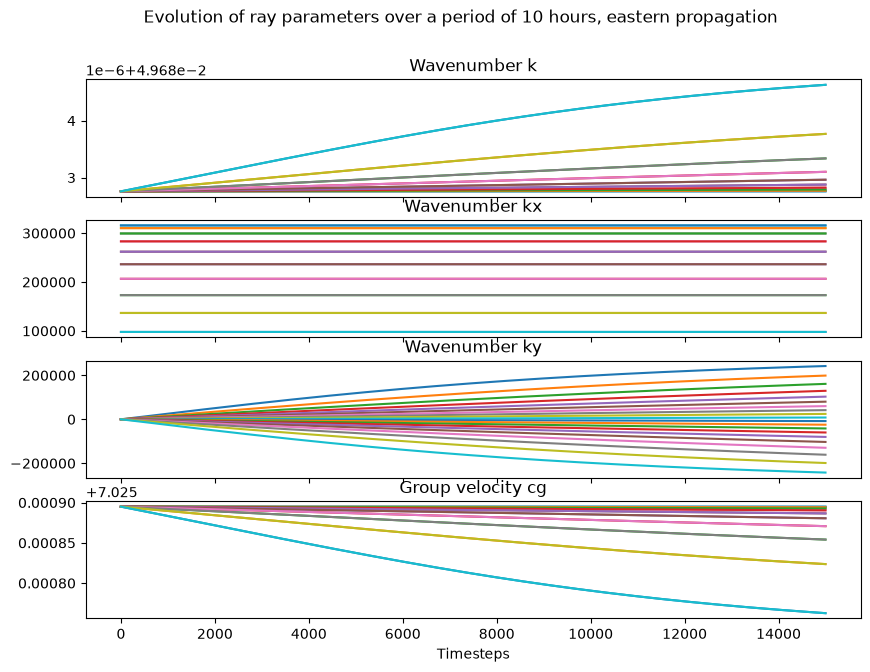

In [2]:
fig, ax = plt.subplots(4,1, figsize=(10,7), sharex=True)
for ray in wt.ray_k:
    ax[0].plot(ray)
    #ax[0].set_xlim(0,10)
for ray in wt.ray_kx:
    ax[1].plot(ray)
for ray in wt.ray_ky:
    ax[2].plot(ray)
for ray in wt.ray_cg:
    ax[3].plot(ray)
ax[0].set_title("Wavenumber k")
ax[1].set_title("Wavenumber kx")
ax[2].set_title("Wavenumber ky")
ax[3].set_title("Group velocity cg")
ax[3].set_xlabel("Timesteps")
fig.suptitle("Evolution of ray parameters over a period of 10 hours, eastern propagation")

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def generate_greatcircle(theta,phi,lambd):
    xi = np.linspace(0,2*np.pi,1000)
    x = (np.cos(xi)*np.cos(phi)-np.sin(xi)*np.sin(theta)*np.sin(phi))*np.cos(lambd) - np.sin(xi)*np.cos(theta)*np.sin(lambd)
    y = (np.cos(xi)*np.cos(phi)-np.sin(xi)*np.sin(theta)*np.sin(phi))*np.sin(lambd) + np.sin(xi)*np.cos(theta)*np.cos(lambd)
    z = np.cos(xi)*np.sin(phi) + np.sin(xi)*np.sin(theta)*np.sin(phi)
    lat = np.arcsin(z)
    lon = np.atan2(y,x)
    return lat, lon

Text(0.5, 0, 'longitude (rad)')

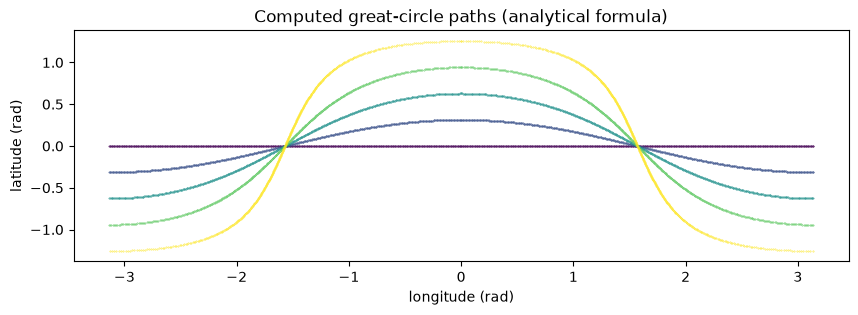

In [4]:
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(10,3))

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,5))

for phi, c in zip(np.linspace(0, np.pi*0.4, 5),colors):
    lat, lon = generate_greatcircle(0, phi, 0)
    ax.scatter(lon, lat, s=0.1, color=c)

ax.set_title("Computed great-circle paths (analytical formula)")
ax.set_ylabel("latitude (rad)")
ax.set_xlabel("longitude (rad)")

